## Bias-Variance Tradeoff

As a machine learning practitioner, it is important to have a good understanding of how to build effective models with high accuracy. A common pitfall in training a model is overfitting and underfitting. Let us look at these topics so the next time you build a model, you would exactly know how to avoid the mistake of overfitting and underfitting.

### Bias-Variance Trade-off
The two variables to measure the effectiveness of your model are bias and variance.

- Bias is the error or difference between points given and points plotted on the line in your training set.

- Variance is the error that occurs due to sensitivity to small changes in the training set.


### bias and variance
- bias : Error caused when a model is too simple to capture the true patterns   in the data.

    - High bias: Model ignores important relationships → underfitting.

    - Low bias: Model captures patterns more accurately.

   -  Example: Using a straight line to fit data that actually follows a curve.

- variance: Error caused when a model is too complex and reacts strongly to small fluctuations in training data.

    - High variance: Model memorizes training data but fails on new data → overfitting.

    - Low variance: Model is stable and generalizes better.

    - Example: A deep decision tree that perfectly fits training points but predicts poorly on unseen data.




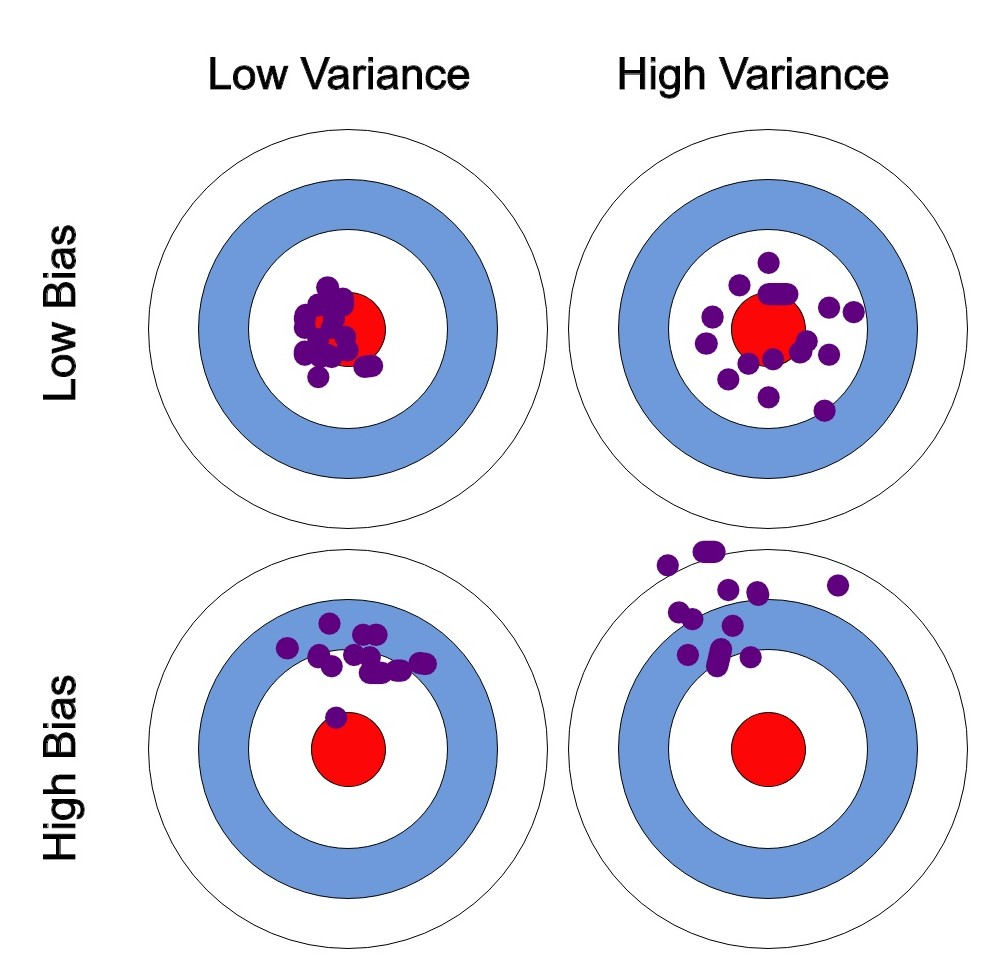

I’ll be explaining bias-variance further with the help of the image above. So please follow along.

- To simply things, let us say, the error is calculated as the difference between predicted and observed/actual value. Now, say we have a model that is very accurate. This means that the error is very less, indicating a low bias and low variance. (As seen on the top-left circle in the image).

- If the variance increases, the data is spread more which results in lower accuracy. (As seen on the top-right circle in the image).

- If the bias increases, the error calculated increases. (As seen on the bottom-left circle in the image).

- High variance and high bias indicate that data is spread with a high error. (As seen on the bottom-right circle in the image).

- This is Bias-Variance Tradeoff. Earlier, I defined bias as a measure of error between what the model captures and what the available data is showing, and variance being the error from sensitivity to small changes in the available data. A model having high variance captures random noise in the data.

- We want to find the best fit line that has low bias and low variance. (As seen on the top-left circle in the image).

Simply we can say that

- bias : How much close to center

- variance: How much gaps between those points

best model have low bias or low variance

### Bias Variance Trade off Graph

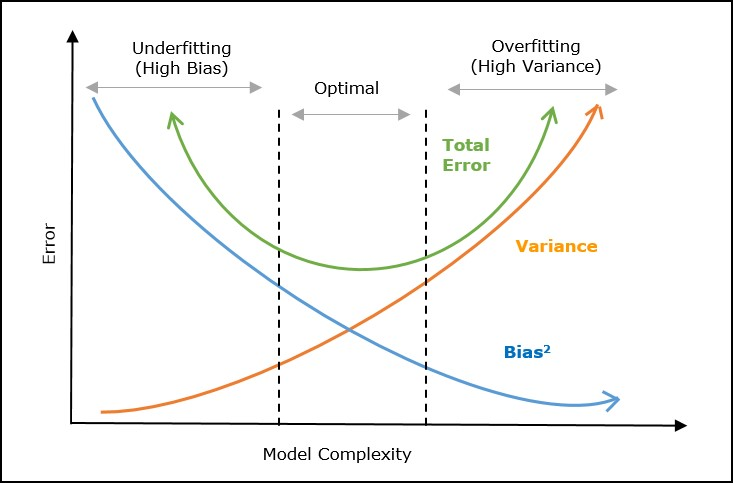

- we use Ensemble models because in thta many models work together and give predictions
- In ensemmble models the built in functionality is such that it finds the trade off point on it's own

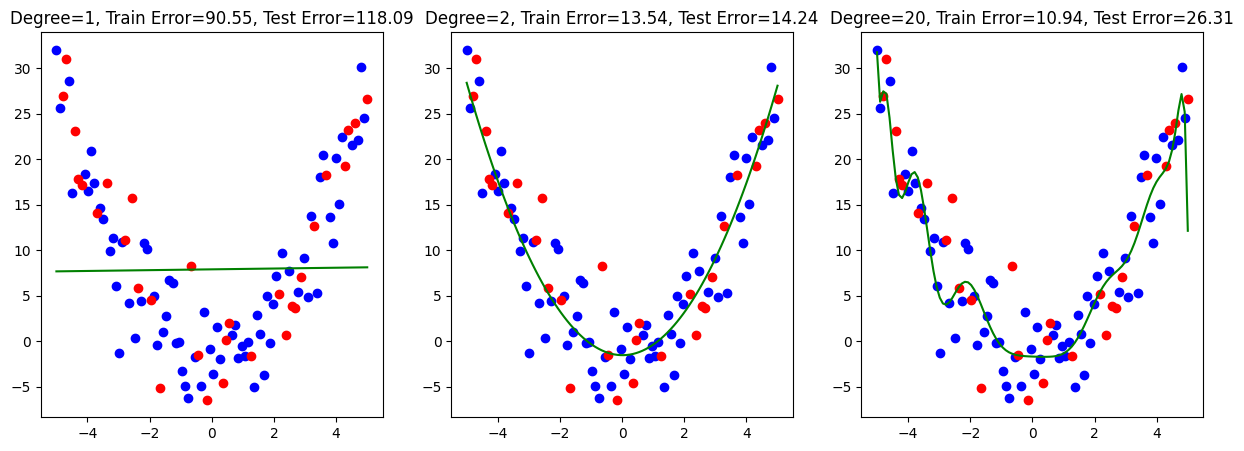

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate random data
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 4, size=100)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Fit polynomial regression models with different degrees
degrees = [1, 2, 20]
plt.figure(figsize=(15, 5))
for i, degree in enumerate(degrees):

    # Generating the data
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train.reshape(-1, 1))
    X_poly_test = poly.transform(X_test.reshape(-1, 1))

    # Creating the model
    model = LinearRegression()

    # Training the model
    model.fit(X_poly_train, y_train)

    # Evaluating the model
    y_pred_train = model.predict(X_poly_train)
    y_pred_test = model.predict(X_poly_test)
    train_error = mean_squared_error(y_train, y_pred_train)
    test_error = mean_squared_error(y_test, y_pred_test)

    # Plotting the results
    plt.subplot(1, len(degrees), i+1)
    plt.scatter(X_train, y_train, color='blue')
    plt.scatter(X_test, y_test, color='red')
    plt.plot(X, model.predict(poly.transform(X.reshape(-1, 1))), color='green')
    plt.title('Degree={}, Train Error={:.2f}, Test Error={:.2f}'.format(degree, train_error, test_error))
plt.show()

- here degree1 is underfitted
- here degree 2 is good fit
- here degree 3 is overfitted

### How do parameters affect our model?
Model complexity keeps increasing as the number of parameters increase. This could result in overfitting, basically increasing variance and decreasing bias.

Our aim is to come up with a point in our model where the decrease in bias is equal to an increase in variance. So how do we do this? Let us look at model fitting.

### Model Fitting
We can find a line that represents the general direction of the points but might not represent every point in the dataset. This would be the best fit model.

### Why not use higher-order polynomials always?
Good question. Sadly, the answer is no. By doing so, we would have created a model that fits our training data very well but fails to generalize beyond the training set (say any testing data that the model was not trained on). Therefore our model performs poorly on the test data giving rise to less accuracy. This problem is called over-fitting. We also say that the model has high variance and low bias.

Similarly, we have another issue. It is called underfitting. It occurs when our model neither fits the training data nor generalizes on the new data (say any testing data that the model was not trained on). Our model is underfitting when we have high bias and low variance.

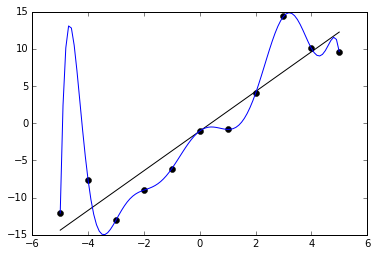

The image above shows a blue line which is a polynomial regression line. The straight black line is that of a linear function. Although the polynomial function is a perfect fit, the linear function can be expected to generalize better. Thus, we can say that the polynomial function is overfitting, on the other hand, the straight line is the best fit. Think of an imaginary line that hardly passes through any of those points. That would be underfitting.

### How to overcome Underfitting & Overfitting for a regression model?
To overcome underfitting or high bias, we can add new parameters to our model so that the model complexity increases thus reducing high bias.

To overcome overfitting, we could use methods like reducing model complexity and regularization.

